In [18]:
import pandas as pd
import numpy as np
from pathlib import Path

from gjive.estimate import estimate_data
from autism.utils import get_elbows, get_region
from gjive.estimate_class import GjiveEstimate
from gjive.estimate_spec import EstimateSpec
from gjive.dataset import GjiveData

In [19]:

DATA_PATH = Path.cwd() / "csvs" / "processed_connectivity_dataset.csv"

df = pd.read_csv(DATA_PATH)

# -------------------------------
# 1. Remove subjects with NaNs
# -------------------------------

df_clean = df.dropna().copy()

print("Original subjects:", len(df))
print("Remaining subjects:", len(df_clean))


# -------------------------------
# 2. Extract metadata
# -------------------------------

subjects = df_clean["SUB_ID"].to_numpy()

dx_group = df_clean["DX_GROUP"].to_numpy()


# Remove non-connectivity columns
df_connectivity = df_clean.drop(
    columns=["SUB_ID", "DX_GROUP"]
)


# -------------------------------
# 3. Create tensor
# -------------------------------

n_subjects = len(df_connectivity)
n_regions = 200

X = np.zeros(
    (n_subjects, n_regions, n_regions),
    dtype=float
)


# -------------------------------
# 4. Fill upper triangle
# -------------------------------

for col in df_connectivity.columns:

    # Column name looks like "1_2"
    region_a, region_b = map(
        int,
        col.split("_")
    )

    # Convert 1-indexed ROI labels to numpy indices
    i = region_a - 1
    j = region_b - 1

    values = df_connectivity[col].to_numpy()

    # Fill both halves because correlation matrices are symmetric
    X[:, i, j] = values
    X[:, j, i] = values


# -------------------------------
# 5. Set diagonal
# -------------------------------

for k in range(n_subjects):
    np.fill_diagonal(X[k], 1)


print("Tensor shape:", X.shape)
print(f'Group Assignments Length: {len(dx_group)}')

Original subjects: 734
Remaining subjects: 690
Tensor shape: (690, 200, 200)
Group Assignments Length: 690


In [20]:
# Group assignment fix

dx_group = dx_group - 1

In [21]:
# Because matrix operations in the estimation algorithm DO NOT swap rows, we can keep this vector consistent.

ROI_PATH = Path().cwd() / "csvs" / "CC200_ROI_labels.csv"

aals = pd.read_csv(ROI_PATH)['AAL'].tolist()

regions = []

for aal in aals:
    region = get_region(aal)
    regions.append(region)

In [22]:
spec = EstimateSpec(
    9,
    [9,9],
    [9] * 690,
)

data = GjiveData.from_real_data(X, group_assignments=dx_group)

estimate = estimate_data(data, spec)

KeyboardInterrupt: 

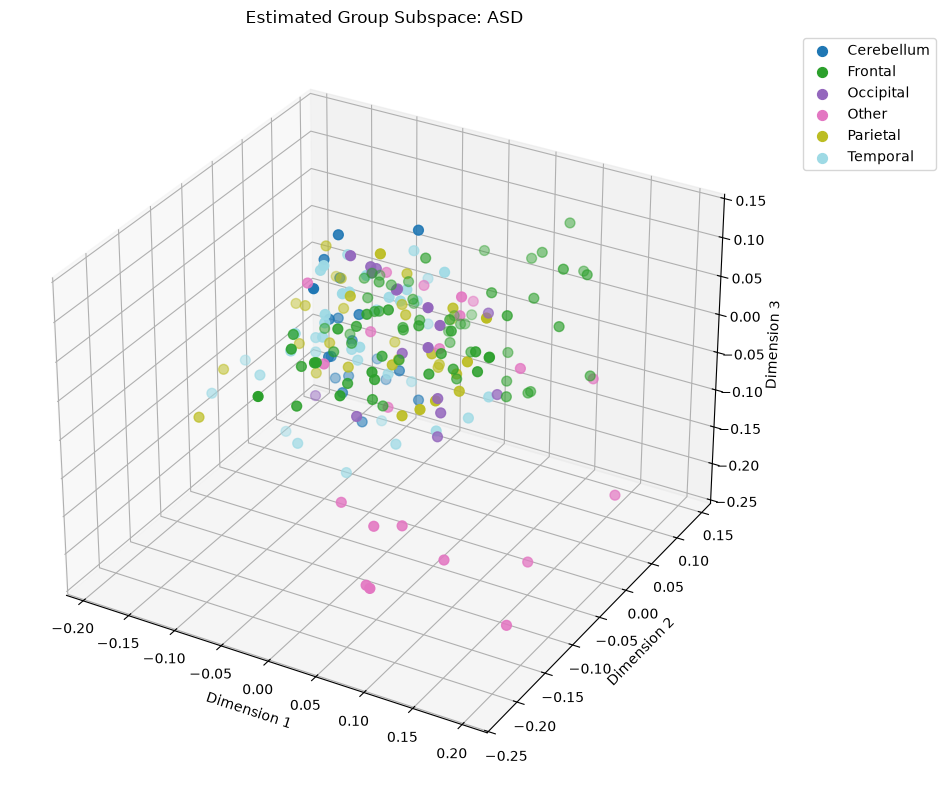

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Coordinates in latent space
coords = estimate.Uf[0][:, :3]      # (200, 3)

# Unique brain region/network labels
labels = np.asarray(regions)
unique_labels = np.unique(labels)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

cmap = plt.colormaps["tab20"]

for i, label in enumerate(unique_labels):
    color = cmap(i / max(1, len(unique_labels) - 1))

    mask = labels == label
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        coords[mask, 2],
        color=color,
        label=label,
        s=50,
    )

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")
ax.set_title("Estimated Group Subspace: ASD")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()